# 06 - Model Evaluation
In this notebook, we evaluate and compare trained models on the test set.

### Planned Evaluation:
1. **Performance Metrics**:
   - Accuracy, Precision, Recall, and F1-Score
   - Focus on **Precision for SPAM** (minimizing False Positives so legitimate emails aren't sent to spam)
2. **Confusion Matrix**:
   - Heatmap of True Positives, True Negatives, False Positives, and False Negatives
3. **Classification Report**:
   - Per-class precision, recall, and f1-score comparison
4. **Model Comparison**:
   - Summary table benchmarking all trained models
5. **Error Analysis**:
   - Inspecting misclassified emails to identify common failure modes

In [4]:
import joblib

# Load the trained Logistic Regression model
model = joblib.load("../models/logistic_regression.pkl")

# Load the TF-IDF vectorizer
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer loaded successfully!")

Model and TF-IDF vectorizer loaded successfully!


In [3]:
import pandas as pd
# Imports pandas so we can load the cleaned dataset.


df = pd.read_csv("../data/processed/cleaned_emails.csv")
# Loads the cleaned email dataset.


X = df["email"]
# X contains the email text that will be classified.


Y = df["label"]
# Y contains the actual labels: HAM or SPAM.

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)
print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

Training emails: 24395
Testing emails: 6099


In [8]:
X_test_tfidf = tfidf.transform(X_test)
# Converts the test emails into TF-IDF numbers
# using the SAME vectorizer that was saved after training.


print("Test TF-IDF shape:", X_test_tfidf.shape)

Test TF-IDF shape: (6099, 100000)


In [9]:
# Use the trained model to predict HAM or SPAM
# for every email in the test dataset.

y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [10]:
from sklearn.metrics import accuracy_score
# Imports the function used to calculate accuracy.


accuracy = accuracy_score(Y_test, y_pred)
# Compares the actual labels (Y_test)
# with the predictions made by our model (y_pred).


print("Accuracy:", accuracy)
# Prints the percentage of test emails classified correctly.

Accuracy: 0.9877029021151008


In [11]:
from sklearn.metrics import classification_report
# Imports a function that calculates precision, recall, and F1-score.


print(classification_report(
    Y_test,                    # Actual labels
    y_pred,                    # Model's predictions
    target_names=["HAM", "SPAM"]
))
# Displays performance separately for HAM and SPAM.

              precision    recall  f1-score   support

         HAM       1.00      0.98      0.99      3234
        SPAM       0.98      0.99      0.99      2865

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099



In [12]:
from sklearn.metrics import confusion_matrix
# Imports the function used to calculate the confusion matrix.


cm = confusion_matrix(Y_test, y_pred)
# Compares the actual labels (Y_test)
# with the model's predictions (y_pred).
#
# The result is a 2×2 matrix:
#
#              Predicted
#              HAM   SPAM
# Actual HAM
# Actual SPAM


print(cm)
# Prints the numerical confusion matrix.

[[3174   60]
 [  15 2850]]


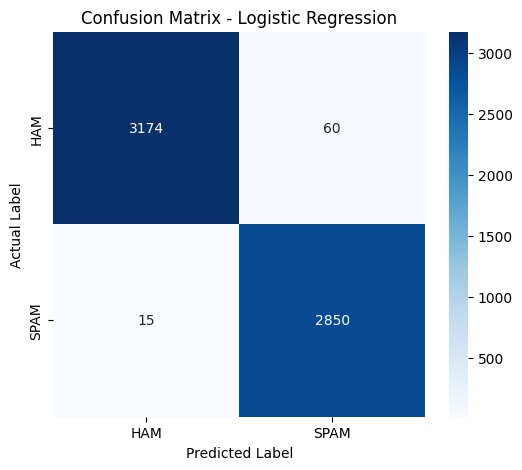

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,              # Shows the numbers inside each cell
    fmt="d",                 # Displays numbers as integers
    cmap="Blues",
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [14]:
import joblib

# Load the trained Naive Bayes model
nb_model = joblib.load("../models/naive_bayes.pkl")

print("Naive Bayes model loaded successfully!")

Naive Bayes model loaded successfully!


In [15]:
# Predict HAM or SPAM for the test emails
nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes predictions generated successfully!")

Naive Bayes predictions generated successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
nb_accuracy = accuracy_score(Y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

# Display precision, recall and F1-score
print("\nNaive Bayes Classification Report:")
print(classification_report(
    Y_test,
    nb_pred,
    target_names=["HAM", "SPAM"]
))

Naive Bayes Accuracy: 0.9888506312510248

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         HAM       0.99      0.99      0.99      3234
        SPAM       0.99      0.99      0.99      2865

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099

